# Spatial + Guided Causal Tracing

This notebook repairs patched-image activations at a fixed YOLO detector layer by replacing selected `[C,H,W]` entries with clean-image values. The primary score is fixed pre-NMS target class logit recovery.

In [1]:
from pathlib import Path
import sys
import importlib

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "CausalTracingViaPatching":
    REPO_ROOT = REPO_ROOT.parent

for path in [REPO_ROOT, REPO_ROOT / "new_experiments", REPO_ROOT / "CausalTracingViaPatching"]:
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)

import pandas as pd
import matplotlib.pyplot as plt

from new_experiments.patch_success_analysis.data import AttackConfig
from new_experiments.patch_success_analysis.experiments import ExperimentConfig, PatchSuccessExperiment
import CausalTracingViaPatching.causal_patching as cp
importlib.reload(cp)

OUTPUT_DIR = REPO_ROOT / "CausalTracingViaPatching" / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR

PosixPath('/Users/ashentide/PycharmProjects/PatchSuccessResearch/CausalTracingViaPatching/outputs')

## Configuration

In [2]:
MAX_EXAMPLES = 20
LAYER_NAME = "model.22"
STEP_FRACS = (0.0, 0.001, 0.002, 0.005, 0.01, 0.02, 0.05, 0.10, 0.20, 0.50, 1.0)
RANDOM_SEEDS = (0, 1, 2, 3, 4)
EVALUATE_FINAL_DETECTION = False
FORCE_REBUILD = False
REQUIRE_MPS = True

exp, attack_cache_path = cp.load_existing_experiment(
    repo_root=REPO_ROOT,
    prefer_dataset="COCO_people",
    prefer_device="mps",
    require_device=REQUIRE_MPS,
)
exp.config.target_layer = LAYER_NAME
cache = exp.get_cache()
print("attack cache:", attack_cache_path)
print("device:", exp.config.attack.device)
print(cache.to_summary())

attack cache: /Users/ashentide/PycharmProjects/PatchSuccessResearch/new_experiments/new_experiments/outputs/patch_success_analysis/cache/attack_pool_d60ec9ed15ee6591.pkl
device: mps
{'cache_key': 'd60ec9ed15ee6591', 'config': {'dataset_path': ['../datasets/COCO_people'], 'patch_path': '../data/patch.png', 'model_path': 'yolo11s.pt', 'output_dir': 'new_experiments/outputs/patch_success_analysis', 'imgsz': 640, 'device': 'cpu', 'target_class_name': 'person', 'conf': 0.01, 'success_thresh': 0.3, 'seed': 17, 'pool_size': 7200, 'n_success': 3000, 'n_fail': 3000, 'apply_patch_after_letterbox': True, 'patch_xy': (0, 0)}, 'balanced_total': 6000, 'balanced_success': 3000, 'balanced_fail': 3000, 'pool_total': 7196, 'pool_success': 3669, 'pool_fail': 3527, 'pool_failed_images': 4, 'failed_paths': ['../datasets/COCO_people/03370_train2017_image501294_ann504782.jpg: no clean detection', '../datasets/COCO_people/03520_train2017_image113192_ann1747866.jpg: no clean detection', '../datasets/COCO_peopl

## Run Or Load

In [3]:
payload = {
    "cache_key": cache.cache_key,
    "layer_name": LAYER_NAME,
    "max_examples": MAX_EXAMPLES,
    "step_fracs": STEP_FRACS,
    "random_seeds": RANDOM_SEEDS,
    "evaluate_final_detection": EVALUATE_FINAL_DETECTION,
    "device": exp.config.attack.device,
    "method_version": 1,
}
result_cache = OUTPUT_DIR / f"causal_repair_{cp.stable_hash(payload)}.pkl"

if result_cache.exists() and not FORCE_REBUILD:
    import pickle
    with result_cache.open("rb") as fh:
        result = pickle.load(fh)
    print("loaded causal repair cache:", result_cache)
else:
    print("building causal repair cache on device:", exp.config.attack.device)
    result = cp.run_repair_experiment(
        exp,
        layer_name=LAYER_NAME,
        max_examples=MAX_EXAMPLES,
        step_fracs=STEP_FRACS,
        random_seeds=RANDOM_SEEDS,
        evaluate_final_detection=EVALUATE_FINAL_DETECTION,
        show_progress=True,
    )
    cp.cache_result(result, result_cache)
    print("saved causal repair cache:", result_cache)

rows = cp.add_marginal_efficiency(result["rows"])
summary = cp.summarize_repair_curves(rows)
skipped = result["skipped"]

cp.save_experiment_outputs({"rows": rows, "summary": summary, "skipped": skipped}, OUTPUT_DIR)
print("rows:", rows.shape)
print("summary:", summary.shape)
print("skipped:", skipped.shape)

building causal repair cache on device: mps


causal repair model.22:   0%|          | 0/20 [00:00<?, ?example/s]

saved causal repair cache: /Users/ashentide/PycharmProjects/PatchSuccessResearch/CausalTracingViaPatching/outputs/causal_repair_3600f53e15ccbe4a.pkl
rows: (3960, 28)
summary: (18, 8)
skipped: (0, 0)


## Summary

In [4]:
display(summary)
display(skipped)

,method,method_family,n_examples,mean_recovery_auc_l2,std_recovery_auc_l2,mean_budget_to_recovery_0p5,median_budget_to_recovery_0p5,final_mean_recovery
0,importance_desc,guided,20,0.900452,0.034699,0.106308,0.089099,0.999998
1,spatial_object_region,spatial,20,0.581032,0.090548,0.520338,0.536193,0.999998
2,spatial_outside_patch,spatial,20,0.481659,0.075516,0.637478,0.656040,0.999998
3,delta_asc,guided,20,0.461118,0.014259,1.000000,1.000000,0.999998
4,random_seed0,guided,20,0.427554,0.062786,0.671999,0.705770,0.999998
5,random_seed4,guided,20,0.426335,0.078933,0.709409,0.703624,0.999998
6,random_seed1,guided,20,0.422976,0.108027,0.699315,0.703207,0.999998
7,random_seed2,guided,20,0.416056,0.075219,0.742272,0.712166,0.999998
8,random_seed3,guided,20,0.414420,0.089620,0.712291,0.707472,0.999998
9,random_delta_matched_seed1,guided,20,0.384654,0.059522,0.763134,0.760994,0.999998


""


## Curves

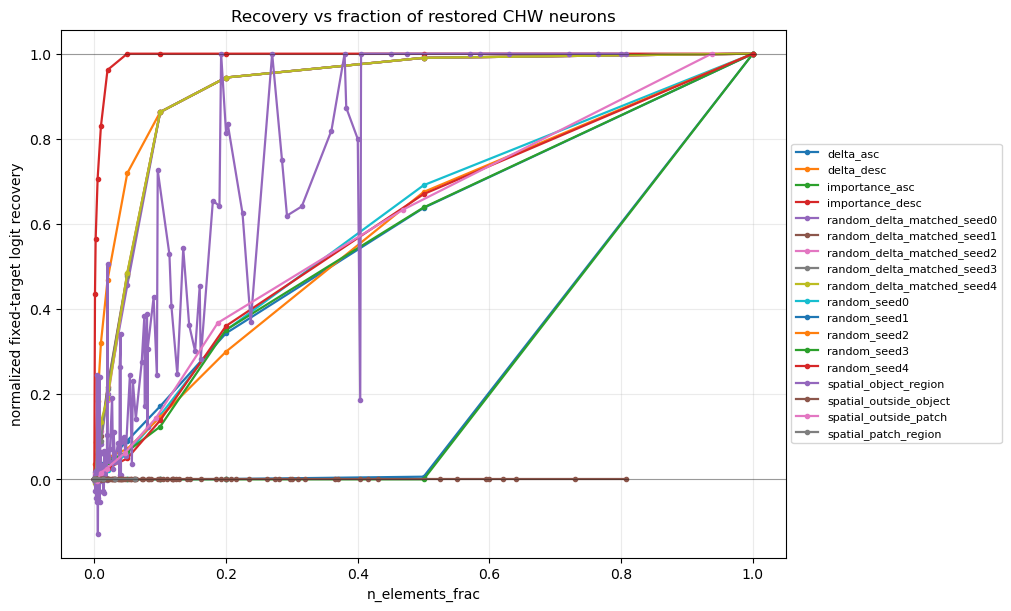

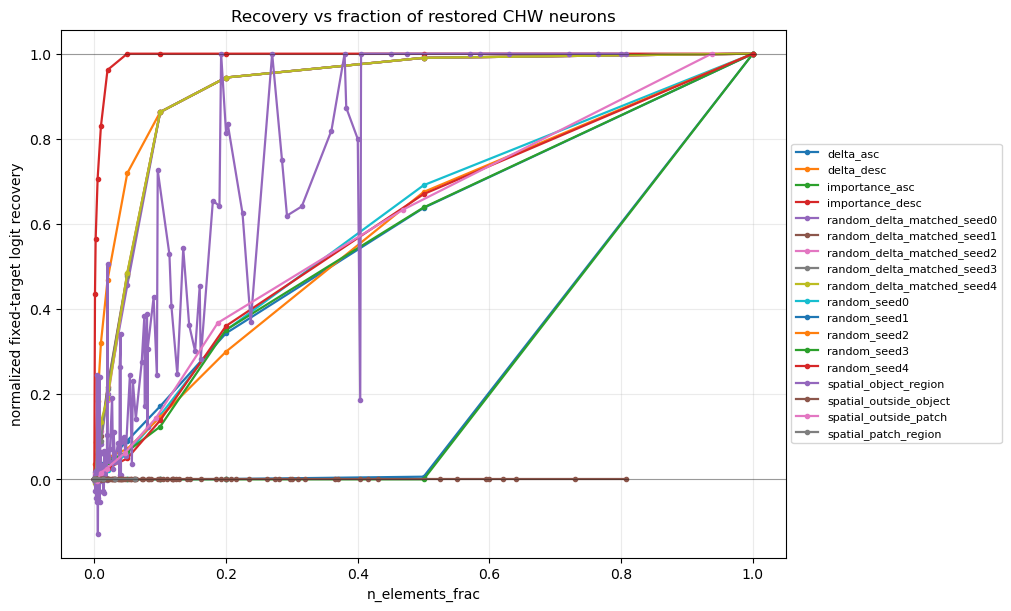

In [5]:
fig = cp.plot_recovery_curves(
    rows,
    x_col="n_elements_frac",
    title="Recovery vs fraction of restored CHW neurons",
    output_path=OUTPUT_DIR / "recovery_vs_neuron_frac.png",
)
fig

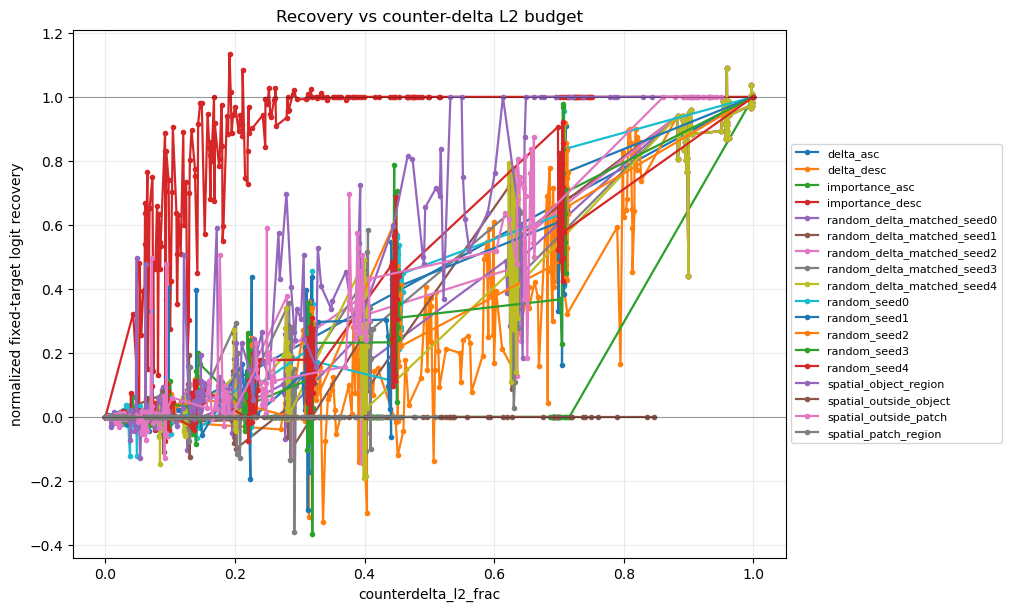

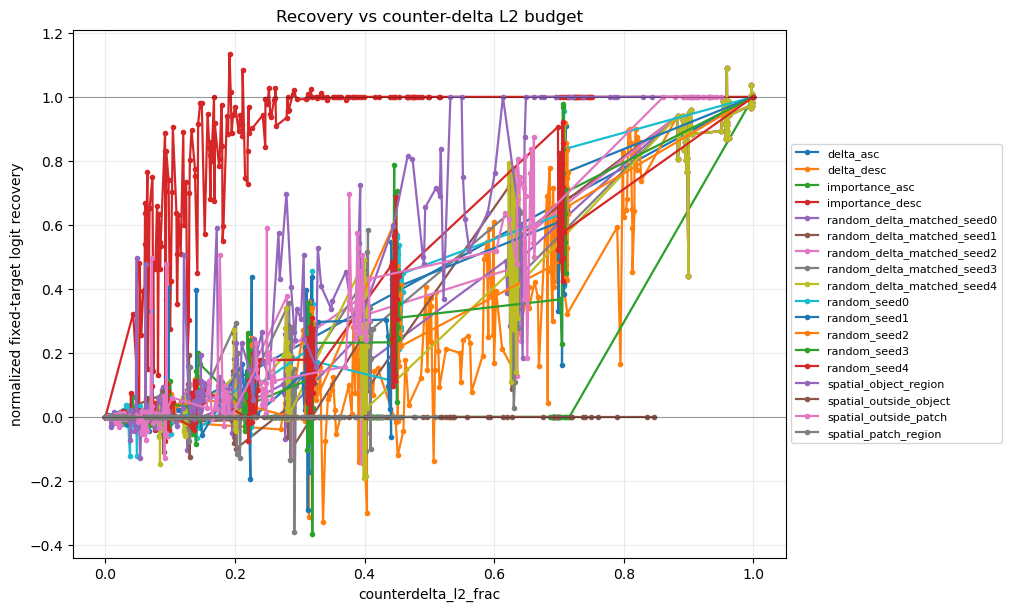

In [6]:
fig = cp.plot_recovery_curves(
    rows,
    x_col="counterdelta_l2_frac",
    title="Recovery vs counter-delta L2 budget",
    output_path=OUTPUT_DIR / "recovery_vs_counterdelta_l2.png",
)
fig

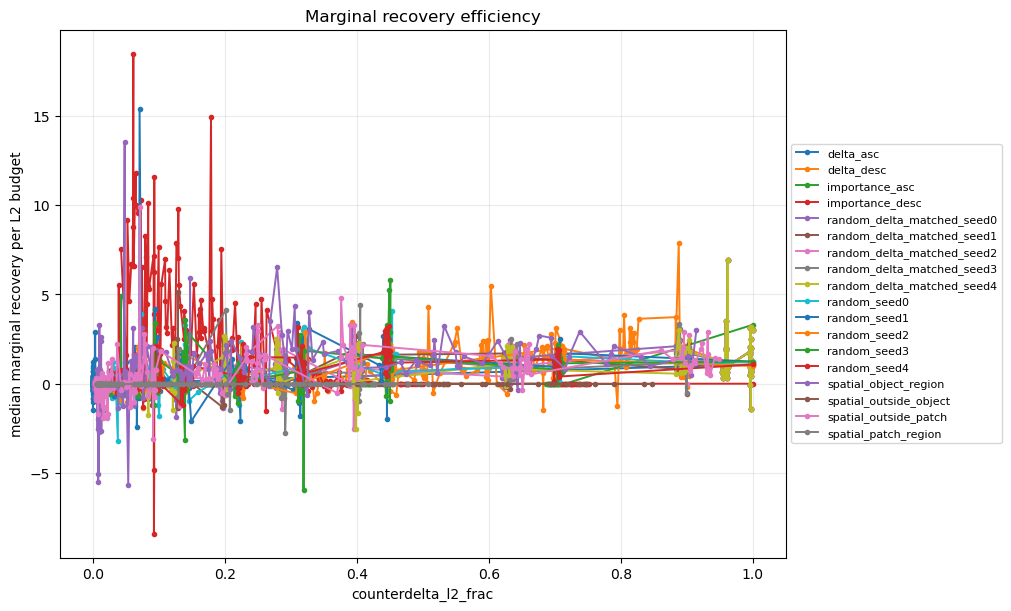

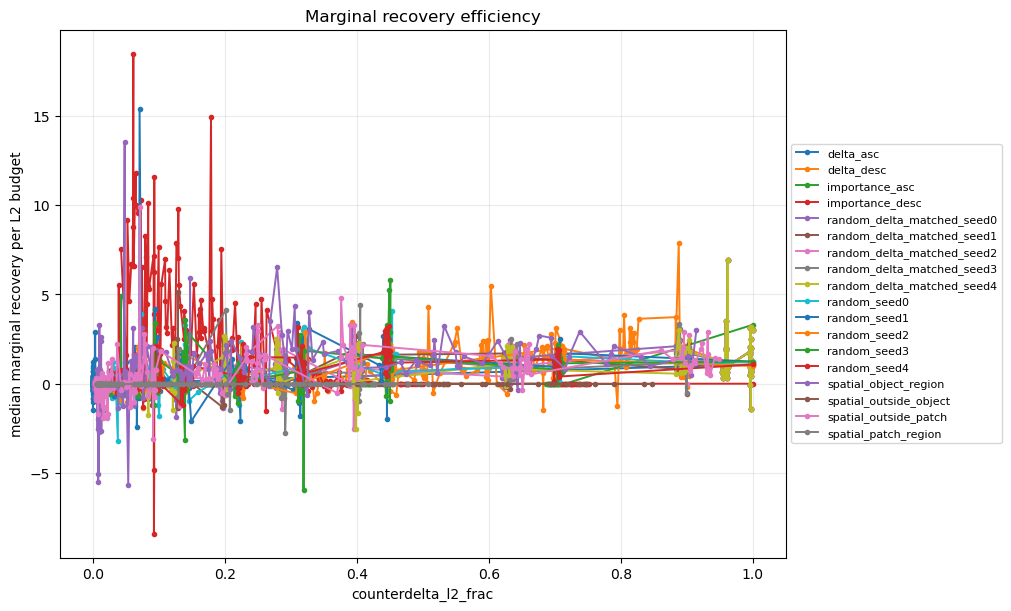

In [7]:
fig = cp.plot_marginal_efficiency(rows, output_path=OUTPUT_DIR / "marginal_efficiency.png")
fig

## Rows Preview

In [ ]:
cols = [
    "path", "method", "method_family", "step_frac", "n_elements_frac",
    "counterdelta_l2_frac", "score", "recovery", "marginal_recovery_per_l2",
    "score_clean", "score_patched", "conf_clean", "conf_patch",
]
display(rows[[c for c in cols if c in rows.columns]].head(50))

,path,method,method_family,step_frac,n_elements_frac,counterdelta_l2_frac,score,recovery,marginal_recovery_per_l2,score_clean,score_patched,conf_clean,conf_patch
0,/Users/ashentide/PycharmProjects/PatchSuccessR...,delta_asc,guided,0.000,0.000000,0.000000,-12.595175,0.000000e+00,NaN,1.539705,-12.595175,0.823421,0.068652
1,/Users/ashentide/PycharmProjects/PatchSuccessR...,delta_asc,guided,0.001,0.001001,0.000002,-12.595194,-1.349391e-06,-0.784883,1.539705,-12.595175,0.823421,0.068652
2,/Users/ashentide/PycharmProjects/PatchSuccessR...,delta_asc,guided,0.002,0.002002,0.000005,-12.595196,-1.484331e-06,-0.039808,1.539705,-12.595175,0.823421,0.068652
3,/Users/ashentide/PycharmProjects/PatchSuccessR...,delta_asc,guided,0.005,0.005000,0.000023,-12.595181,-4.048174e-07,0.060947,1.539705,-12.595175,0.823421,0.068652
4,/Users/ashentide/PycharmProjects/PatchSuccessR...,delta_asc,guided,0.010,0.010000,0.000070,-12.595251,-5.397566e-06,-0.105079,1.539705,-12.595175,0.823421,0.068652
5,/Users/ashentide/PycharmProjects/PatchSuccessR...,delta_asc,guided,0.020,0.020000,0.000225,-12.594877,2.105051e-05,0.171173,1.539705,-12.595175,0.823421,0.068652
6,/Users/ashentide/PycharmProjects/PatchSuccessR...,delta_asc,guided,0.050,0.050000,0.001067,-12.595348,-1.227946e-05,-0.039563,1.539705,-12.595175,0.823421,0.068652
7,/Users/ashentide/PycharmProjects/PatchSuccessR...,delta_asc,guided,0.100,0.100000,0.003611,-12.582457,8.997743e-04,0.358519,1.539705,-12.595175,0.823421,0.068652
8,/Users/ashentide/PycharmProjects/PatchSuccessR...,delta_asc,guided,0.200,0.200000,0.012634,-12.580660,1.026887e-03,0.014088,1.539705,-12.595175,0.823421,0.068652
9,/Users/ashentide/PycharmProjects/PatchSuccessR...,delta_asc,guided,0.500,0.500000,0.078915,-12.151414,3.139474e-02,0.458168,1.539705,-12.595175,0.823421,0.068652


: 